In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from torch.amp import GradScaler, autocast
import os
import numpy as np
import matplotlib.pyplot as plt


# для colab
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
class TimeIntervalEmbedding(nn.Module):
    # разница во времени между книгами
    def __init__(self, hidden_dim, max_interval=365):
        super().__init__()
        self.emb = nn.Embedding(max_interval + 1, hidden_dim, padding_idx=0)

    def forward(self, intervals):
        intervals = intervals.clamp(0, self.emb.num_embeddings - 1).long()
        return self.emb(intervals)

In [3]:
class SASRecTiSASRec(nn.Module):
    # модель с временными интервалами и признаком повтора

    def __init__(self, cnt_item, max_seq_len=30, hidden_dim=64,
                 num_heads=2, num_layers=2, dropout=0.2,
                 cnt_authors=0, cnt_categories=0, max_interval=365):
        super().__init__()

        self.max_seq_len = max_seq_len
        self.hidden_dim = hidden_dim

        self.item_emb = nn.Embedding(cnt_item + 1, hidden_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_seq_len, hidden_dim)
        self.time_interval_emb = TimeIntervalEmbedding(hidden_dim, max_interval)
        self.repeat_emb = nn.Embedding(2, hidden_dim)

        if cnt_authors > 0:
            self.author_emb = nn.Embedding(cnt_authors + 1, hidden_dim, padding_idx=0)
        if cnt_categories > 0:
            self.category_emb = nn.Embedding(cnt_categories + 1, hidden_dim, padding_idx=0)

        self.emb_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

        transformer_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads,
            dim_feedforward=4 * hidden_dim, dropout=dropout,
            batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(transformer_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.output = nn.Linear(hidden_dim, cnt_item + 1)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, item_ids, intervals, repeats, author_ids=None, category_ids=None):
        batch_size, seq_len = item_ids.shape

        item_emb = self.item_emb(item_ids)
        pos = torch.arange(seq_len, device=item_ids.device).unsqueeze(0)
        pos_emb = self.pos_emb(pos)
        interval_emb = self.time_interval_emb(intervals)
        repeat_emb = self.repeat_emb(repeats)

        x = item_emb + pos_emb + interval_emb + repeat_emb

        if hasattr(self, 'author_emb') and author_ids is not None:
            x = x + self.author_emb(author_ids)
        if hasattr(self, 'category_emb') and category_ids is not None:
            x = x + self.category_emb(category_ids)

        x = self.emb_norm(x)
        x = self.dropout(x)

        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=item_ids.device), diagonal=1
        ).bool()

        x = self.transformer(x, mask=causal_mask, is_causal=False)
        x = self.layer_norm(x)

        logits = self.output(x)
        return logits

In [4]:
def negative_sampling_loss(scores, positive_items, cnt_item, num_negatives=100):
    batch_size = scores.shape[0]
    pos_scores = scores[torch.arange(batch_size), positive_items]
    neg_ids = torch.randint(1, cnt_item, (batch_size, num_negatives), device=scores.device)
    neg_scores = scores.gather(1, neg_ids)
    pos_term = -F.logsigmoid(pos_scores)
    neg_term = -F.logsigmoid(-neg_scores).sum(dim=1)
    return (pos_term + neg_term).mean()

In [5]:
def ndcg_at_k(rel, pred, k=10):
    ndcg = 0.0
    if rel in pred[:k]:
        pred_list = list(pred[:k])
        score = pred_list.index(rel) + 1
        ndcg = 1.0 / np.log2(score + 1)
        return ndcg
    return ndcg


def recall_at_k(rel, pred, k=10):
    recall = 1.0 if rel in pred[:k] else 0.0
    return recall

In [6]:
# для colab
# data = torch.load('/content/drive/MyDrive/preprocessed_data_exp.pt')

data = torch.load('preprocessed_data_exp.pt')
train_inputs = data['train_inputs']
train_targets = data['train_targets']
train_authors = data['train_authors']
train_categories = data['train_categories']
train_times = data['train_timestamps']
validate_inputs = data['validate_inputs']
validate_targets = data['validate_targets']
validate_authors = data['validate_authors']
validate_categories = data['validate_categories']
validate_times = data['validate_timestamps']
cnt_item = data['cnt_item']
cnt_author = data['cnt_author']
cnt_category = data['cnt_category']

print(f"Train: {len(train_inputs)} примеров")
print(f"Validate: {len(validate_inputs)} примеров")

Train: 554526 примеров
Validate: 120934 примеров


In [7]:
# находим интервалы и повторы
def prepare_intervals_and_repeats(inputs, times):
    intervals = torch.zeros_like(times)
    mask = (times[:, 1:] > 0) & (times[:, :-1] > 0)
    intervals[:, 1:] = torch.where(mask, times[:, 1:] - times[:, :-1], torch.zeros_like(times[:, 1:]))

    repeats = torch.zeros_like(inputs)
    for b in range(len(inputs)):
        seen = set()
        for p in range(len(inputs[b])):
            if inputs[b][p] > 0:
                if inputs[b][p].item() in seen:
                    repeats[b][p] = 1
                else:
                    seen.add(inputs[b][p].item())

    return intervals.long(), repeats.long()


train_intervals, train_repeats = prepare_intervals_and_repeats(train_inputs, train_times)
val_intervals, val_repeats = prepare_intervals_and_repeats(validate_inputs, validate_times)

In [8]:
batch_size = 32
train_dataset = TensorDataset(train_inputs, train_targets,
                               train_intervals, train_repeats,
                               train_authors, train_categories)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = SASRecTiSASRec(
    cnt_item=cnt_item, max_seq_len=30,
    hidden_dim=64, num_heads=2, num_layers=2, dropout=0.2,
    cnt_authors=cnt_author, cnt_categories=cnt_category
).to(device)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Параметров: 20,731,933


In [10]:
# валидация
def check_metrics_validate(model, validate_inputs, validate_targets,
                           val_intervals, val_repeats,
                           validate_authors, validate_categories,
                           k=10, batch_size=16):
    model.eval()
    ndcg_scores, recall_scores = [], []

    with torch.no_grad():
        for i in tqdm(range(0, len(validate_inputs), batch_size), desc="Validate"):
            batch_input = validate_inputs[i:i+batch_size].to(device)
            batch_target = validate_targets[i:i+batch_size]
            batch_intervals = val_intervals[i:i+batch_size].to(device)
            batch_repeats = val_repeats[i:i+batch_size].to(device)
            batch_authors = validate_authors[i:i+batch_size].to(device)
            batch_categories = validate_categories[i:i+batch_size].to(device)

            logits = model(batch_input, batch_intervals, batch_repeats,
                          batch_authors, batch_categories)
            scores = logits[:, -1, :]
            _, pred = torch.topk(scores, k=k, dim=1)
            pred = pred.cpu().numpy()

            for j in range(len(batch_target)):
                target = batch_target[j].item()
                ndcg_scores.append(ndcg_at_k(target, pred[j], k))
                recall_scores.append(recall_at_k(target, pred[j], k))

    model.train()
    return np.mean(ndcg_scores), np.mean(recall_scores)

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scaler = GradScaler('cuda')
os.makedirs('checkpoints', exist_ok=True)

best_ndcg = 0.0
check_validate = 2
patience = 2
patience_counter = 0

history = {
    'epoch': [],
    'train_loss': [],
    'validate_ndcg': [],
    'validate_recall': []
}

In [12]:
print("TiSASRec + RepeatNet")

for epoch in range(1, 25):
    model.train()
    total_loss = 0

    for inputs, targets, intervals, repeats, authors, categories in tqdm(train_loader, desc=f"Epoch {epoch}/25"):
        inputs, targets = inputs.to(device), targets.to(device)
        intervals = intervals.to(device)
        repeats = repeats.to(device)
        authors, categories = authors.to(device), categories.to(device)

        with autocast('cuda'):
            logits = model(inputs, intervals, repeats, authors, categories)
            loss = negative_sampling_loss(logits[:, -1, :], targets, cnt_item)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)

    if epoch % check_validate == 0:
        validate_ndcg, validate_recall = check_metrics_validate(
            model, validate_inputs, validate_targets,
            val_intervals, val_repeats,
            validate_authors, validate_categories, k=10, batch_size=16
        )
        history['validate_ndcg'].append(validate_ndcg)
        history['validate_recall'].append(validate_recall)

        print(f'Epoch {epoch:2d} | Train Loss: {avg_loss:.4f} | Validate NDCG@10: {validate_ndcg:.4f} | Validate Recall@10: {validate_recall:.4f}')

        if validate_ndcg > best_ndcg:
            best_ndcg = validate_ndcg
            patience_counter = 0
            torch.save(model.state_dict(), 'checkpoints/tisasrec_best.pth')
            print(f'Лучшая модель сохранена (NDCG@10: {best_ndcg:.4f})')
        else:
            patience_counter += 1
            print(f'Нет улучшения ({patience_counter}/{patience})')

        if patience_counter >= patience:
            print(f'Ранняя остановка на эпохе {epoch}')
            break
    else:
        history['validate_ndcg'].append(None)
        history['validate_recall'].append(None)
        print(f'Epoch {epoch:2d} | Train Loss: {avg_loss:.4f}')

print(f'Лучшая метрика NDCG@10 на валидации: {best_ndcg:.4f}')

TiSASRec + RepeatNet


Epoch 1/25: 100%|██████████| 17329/17329 [06:19<00:00, 45.67it/s]


Epoch  1 | Train Loss: 3.2437


Validate: 100%|██████████| 7559/7559 [00:38<00:00, 194.62it/s]


Epoch  2 | Train Loss: 2.1745 | Validate NDCG@10: 0.4200 | Validate Recall@10: 0.5126
Лучшая модель сохранена (NDCG@10: 0.4200)


...

Epoch  8 | Train Loss: 1.3468 | Validate NDCG@10: 0.4283 | Validate Recall@10: 0.5268
Нет улучшения (1/2)


Epoch 9/25: 100%|██████████| 17329/17329 [06:18<00:00, 45.83it/s]


Epoch  9 | Train Loss: 1.2984


Validate: 100%|██████████| 7559/7559 [00:38<00:00, 194.33it/s]

Epoch 10 | Train Loss: 1.2861 | Validate NDCG@10: 0.4273 | Validate Recall@10: 0.5288
Нет улучшения (2/2)
Ранняя остановка на эпохе 10
Лучшая метрика NDCG@10 на валидации: 0.4328


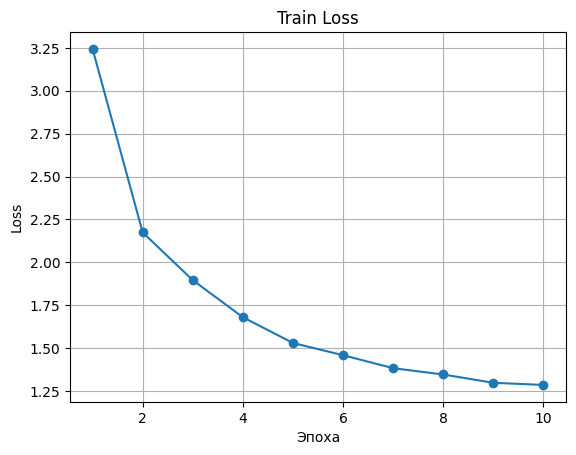

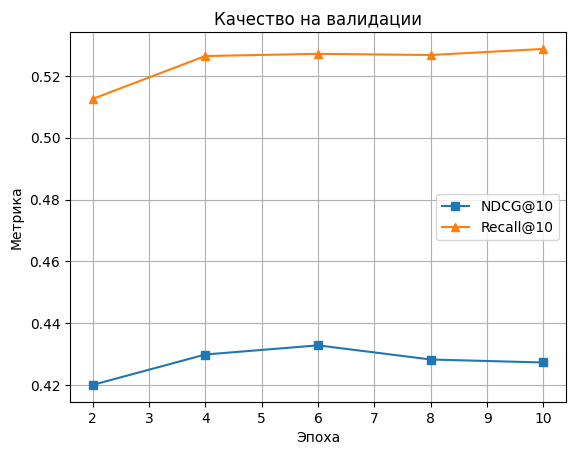

In [13]:
plt.figure()
plt.plot(history['epoch'], history['train_loss'], marker='o')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Train Loss')
plt.grid(True)
plt.show()

val_epochs = [e for e, v in zip(history['epoch'], history['validate_ndcg']) if v is not None]
val_ndcg_clean = [v for v in history['validate_ndcg'] if v is not None]
val_recall_clean = [v for v in history['validate_recall'] if v is not None]

plt.figure()
plt.plot(val_epochs, val_ndcg_clean, marker='s', label='NDCG@10')
plt.plot(val_epochs, val_recall_clean, marker='^', label='Recall@10')
plt.xlabel('Эпоха')
plt.ylabel('Метрика')
plt.title('Качество на валидации')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
test_inputs = data['test_inputs']
test_targets = data['test_targets']
test_times = data['test_timestamps']
test_authors = data['test_authors']
test_categories = data['test_categories']
k_values = [10, 50, 100]

test_intervals, test_repeats = prepare_intervals_and_repeats(test_inputs, test_times)

model.load_state_dict(torch.load('checkpoints/tisasrec_best.pth', map_location=device))
model.eval()

ndcg_scores = {k: [] for k in k_values}
recall_scores = {k: [] for k in k_values}

with torch.no_grad():
    for i in tqdm(range(len(test_inputs)), desc="Тест"):
        inp = test_inputs[i].unsqueeze(0).to(device)
        intervals = test_intervals[i].unsqueeze(0).to(device)
        repeats = test_repeats[i].unsqueeze(0).to(device)
        auth = test_authors[i].unsqueeze(0).to(device)
        cat = test_categories[i].unsqueeze(0).to(device)
        target = test_targets[i].item()
        scores = model(inp, intervals, repeats, auth, cat)[0, -1, :]
        _, pred = torch.topk(scores, k=max(k_values), dim=0)
        pred = pred.cpu().numpy()
        for k in k_values:
            ndcg_scores[k].append(ndcg_at_k(target, pred, k))
            recall_scores[k].append(recall_at_k(target, pred, k))

for k in k_values:
    print(f"NDCG@{k:<3}   {np.mean(ndcg_scores[k]):.4f}")
    print(f"Recall@{k:<3} {np.mean(recall_scores[k]):.4f}")
    print()

Тест: 100%|██████████| 118972/118972 [04:53<00:00, 405.46it/s]


NDCG@10    0.4408
Recall@10  0.5340

NDCG@50    0.4492
Recall@50  0.5722

NDCG@100   0.4523
Recall@100 0.5912

